In [49]:
import os
os.environ['KERAS_BACKEND'] = 'torch'
import keras

In [50]:
from keras.models import Sequential, Model

from keras.layers import (
    Dense, Input, ReLU, Flatten, Rescaling, Convolution2D
    , Reshape, MaxPooling2D, GlobalAveragePooling2D
    , Dropout, RandomFlip, RandomRotation, RandomCrop, RandomShear, RandomTranslation
    , RandomZoom, RandomColorDegeneration, RandomErasing
)

from keras.losses import SparseCategoricalCrossentropy, CategoricalCrossentropy
from keras.metrics import Accuracy
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping, LearningRateScheduler, ReduceLROnPlateau

from keras.datasets import mnist, cifar10

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [51]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=1)
print(f'{x_train.shape} - {x_val.shape}')

(40000, 32, 32, 3) - (10000, 32, 32, 3)


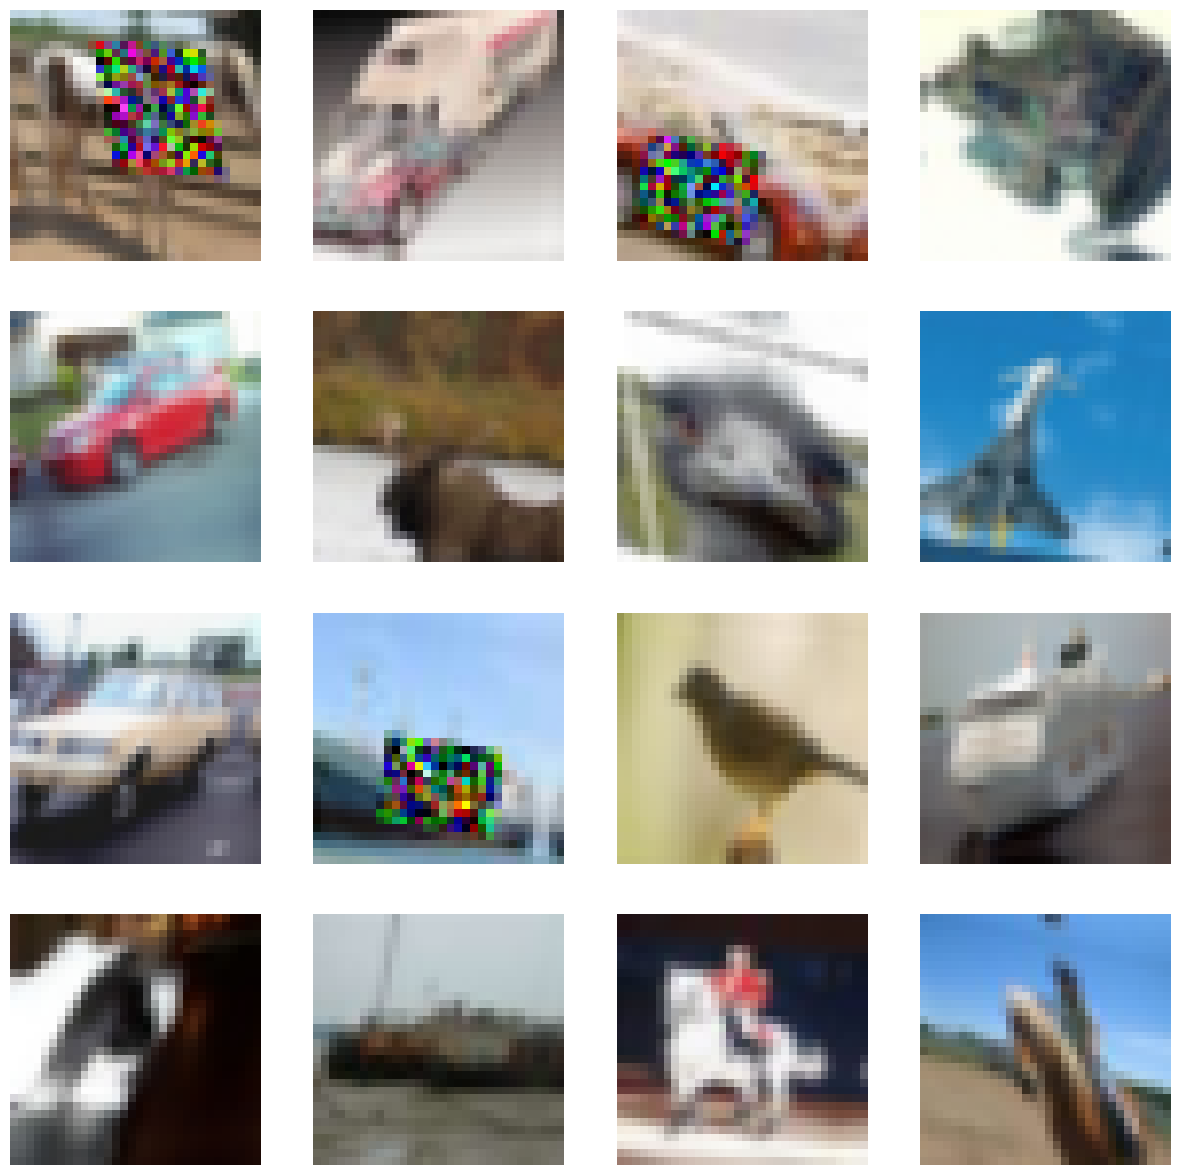

In [52]:
data_augmenter = Sequential([
    RandomFlip('horizontal')
    , RandomErasing(factor=0.5, scale=(0.1, 0.25))
    , RandomShear(0.25, 0.25)
    ])

sample_batch = x_train[:16]

img_augmented = data_augmenter(sample_batch, training=True).cpu().numpy().astype(np.uint8)
img_augmented.shape

plt.figure(figsize=(15, 15))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(img_augmented[i])
    plt.axis('off')
plt.show()


In [53]:
def build_cnn_model() -> Sequential:
    model = Sequential([
        Input((32, 32, 3))

        , RandomFlip('horizontal')
        , RandomErasing(factor=0.5, scale=(0.1, 0.25))
        # , RandomShear(0.25, 0.25)
        
        , Rescaling(1./255)

        , Convolution2D(64, 3, activation='relu', padding='same')
        , Convolution2D(64, 3, activation='relu', padding='same')
        , MaxPooling2D(2)

        , Convolution2D(128, 3, activation='relu', padding='same')
        , Convolution2D(128, 3, activation='relu', padding='same')
        , MaxPooling2D(2)

        , Convolution2D(256, 3, activation='relu', padding='same')
        , Convolution2D(256, 3, activation='relu', padding='same')
        , MaxPooling2D(2)

        , GlobalAveragePooling2D()

        # , Flatten()
        # , Dense(64, activation='relu')
        # , Dropout(0.5)

        , Dense(10, activation='softmax')

    ])

    model.compile(
        optimizer=Adam(), loss=SparseCategoricalCrossentropy()
        , metrics=['accuracy']
        )

    return model

cnn = build_cnn_model()
cnn.summary()

callbacks = [
    ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True, save_freq='epoch')
    , EarlyStopping(monitor='val_loss', min_delta=2, patience=1)
]

cnn.fit(x_train, y_train, batch_size=512
        , epochs=50, validation_data=(x_val, y_val)
        , callbacks=callbacks
        )


Model: "sequential_42"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_42 (RandomFlip)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_erasing_42               │ (None, 32, 32, 3)      │             0 │
│ (RandomErasing)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_9 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,147,978 (4.38 MB)

 Trainable params: 1,147,978 (4.38 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.2308 - loss: 2.0196 - val_accuracy: 0.3320 - val_loss: 1.7759
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.3710 - loss: 1.6631 - val_accuracy: 0.4306 - val_loss: 1.4976


In [54]:
cnn.history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

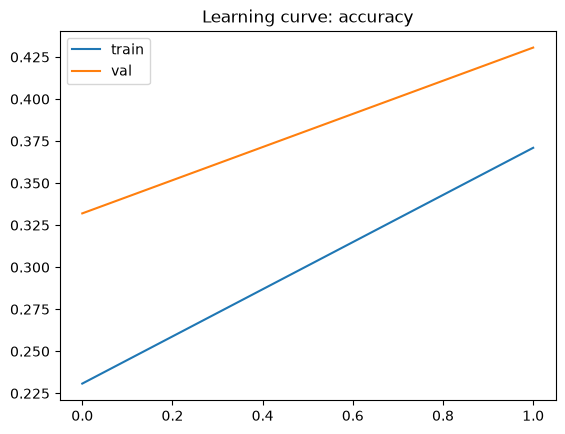

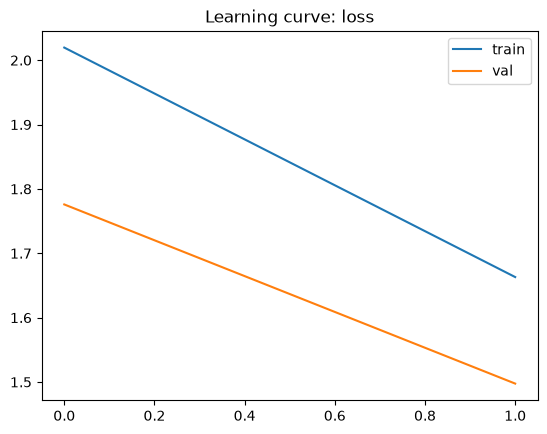

In [55]:
def plot_evaluation(history: dict, metrics: list[str] = ['accuracy']) -> None:
    metrics.append('loss')
    for metric in metrics:
        plt.Figure(figsize=(10, 7))
        plt.title(f'Learning curve: {metric}')
        plt.plot(history[metric], label='train')
        plt.plot(history[f'val_{metric}'], label='val')
        plt.legend()
        plt.show()

plot_evaluation(cnn.history.history)

In [ ]:
from keras.models import load_model, save_model

best_model = load_model('best_model.keras')
best_model.summary()

Model: "sequential_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_40 (RandomFlip)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_erasing_40               │ (None, 32, 32, 3)      │             0 │
│ (RandomErasing)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_8 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,443,936 (13.14 MB)

 Trainable params: 1,147,978 (4.38 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,295,958 (8.76 MB)